In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table, join
from astroquery.vizier import Vizier
from types import SimpleNamespace
import re
from astropy.io import ascii,fits
from astropy import units as u
from astropy.table import Table, vstack, hstack
import line_ratios as lr
from scipy.optimize import curve_fit
from astropy.cosmology import WMAP9 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../')
# import src.ifu_tools.line_ratios as lr

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()

True

In [2]:
a = fits.open('MW_44fields_emline_table_v1.0.fits')
b = fits.open('MW_44fields_main_table_v1.0.fits')
test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

In [3]:
linetab = Table(a[1].data)

In [4]:
maintab = Table(b[1].data)
crit1 = (maintab['LEAD_LINE'] == 'O3_2')|(maintab['LEAD_LINE'] == 'O3_1')
crit2 = ((np.char.find(maintab['OTHER_LINES'], 'O3_2'))>-1)|((np.char.find(maintab['OTHER_LINES'], 'O3_1'))>-1)
detected = (crit1|crit2).astype(int)
maintab['DETECTED?_OIII'] = detected

linekeys = {'oiii5007':'O3_2',
         'oiii4959':'O3_1',
         'oii':'O2',
         'halpha':'Ha',
         'hbeta':'Hb'}

def add_fluxes(mt,lt):
    to_join = []
    colnames = []
    for name in list(linekeys.keys()):
        lines = lt[lt['IDENT'] == linekeys.get(name)]

        flux_to_join = lines[['UNIQUE_ID', 'F_3KRON', 'F_3KRON_ERR', 'LAMBDA_SN']]
        flux_to_join.rename_column('F_3KRON', 'WF'+name+'_flux')
        flux_to_join.rename_column('F_3KRON_ERR', 'WF'+name+'_flux_err')
        flux_to_join.rename_column('LAMBDA_SN', 'WF'+name+'_centroid')

        colnames.append('WF'+name+'_flux')
        colnames.append('WF'+name+'_flux_err')
        colnames.append('WF'+name+'_centroid')

        to_join.append(flux_to_join)
    
    for t in to_join:
        mt = join(mt, t, keys='UNIQUE_ID', join_type='left')

    for c in colnames:
        if c in mt.colnames and hasattr(mt[c], 'filled'):
            mt[c] = mt[c].filled(np.nan)

    return mt

def add_oiii_fluxes(mt, lt):
    oiii_5007_lines = lt[lt['IDENT'] == 'O3_2']
    oiii_5007_to_join = oiii_5007_lines[['UNIQUE_ID', 'F_3KRON', 'F_3KRON_ERR', 'LAMBDA_SN']]
    oiii_5007_to_join.rename_column('F_3KRON', 'WFoiii5007_flux')
    oiii_5007_to_join.rename_column('F_3KRON_ERR', 'WFoiii5007_flux_err')
    oiii_5007_to_join.rename_column('LAMBDA_SN', 'WFoiii5007_centroid')

    oiii_4959_lines = lt[lt['IDENT'] == 'O3_1']
    oiii_4959_to_join = oiii_4959_lines[['UNIQUE_ID', 'F_3KRON', 'F_3KRON_ERR', 'LAMBDA_SN']]
    oiii_4959_to_join.rename_column('F_3KRON', 'WFoiii4959_flux')
    oiii_4959_to_join.rename_column('F_3KRON_ERR', 'WFoiii4959_flux_err')
    oiii_4959_to_join.rename_column('LAMBDA_SN', 'WFoiii4959_centroid')

    hbeta_lines = lt[lt['IDENT'] == 'Hb']
    hbeta_to_join = hbeta_lines[['UNIQUE_ID', 'F_3KRON', 'F_3KRON_ERR', 'LAMBDA_SN']]
    hbeta_to_join.rename_column('F_3KRON', 'WFhbeta_flux')
    hbeta_to_join.rename_column('F_3KRON_ERR', 'WFhbeta_flux_err')
    hbeta_to_join.rename_column('LAMBDA_SN', 'WFhbeta_centroid')

    merged_table = join(mt, oiii_5007_to_join, keys='UNIQUE_ID', join_type='left')
    merged_table = join(merged_table, oiii_4959_to_join, keys='UNIQUE_ID', join_type='left')
    merged_table = join(merged_table, hbeta_to_join, keys='UNIQUE_ID', join_type='left')
    for col in ['WFoiii5007_flux', 'WFoiii5007_flux_err', 'WFoiii5007_centroid',
                'WFoiii4959_flux', 'WFoiii4959_flux_err', 'WFoiii4959_centroid',
                'WFhbeta_flux', 'WFhbeta_flux_err', 'WFhbeta_centroid']:
        if col in merged_table.colnames and hasattr(merged_table[col], 'filled'):
            merged_table[col] = merged_table[col].filled(np.nan)

    return merged_table


maintab=add_fluxes(maintab,linetab)

In [5]:
crit3 = (maintab['LEAD_LINE'] == 'Hb')|((np.char.find(maintab['OTHER_LINES'], 'Hb'))>-1)
maintab['DETECTED?_Hb'] = crit3.astype(int)


In [6]:
linetab

UNIQUE_ID,POINTING_ID,OBJ_ID,RID,IDENT,COMMENT,SN,RA_SN,DEC_SN,LAMBDA_SN,RA_PEAK_SN,DEC_PEAK_SN,LAMBDA_PEAK_SN,LAMBDA_NB_MIN,LAMBDA_NB_MAX,RA_1MOM,DEC_1MOM,R_KRON,F_KRON,F_2KRON,F_3KRON,F_4KRON,F_KRON_ERR,F_2KRON_ERR,F_3KRON_ERR,F_4KRON_ERR,BORDER_FLAG
int64,int16,int16,int16,str5,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
101001006,1,1,1,O2,-,42.24084387238719,53.06025679883623,-27.813499272544774,4886.836172204812,53.06021005230657,-27.81346573752803,4886.326171875,4874.451171875,4893.201171875,53.06021364319668,-27.813449807787595,0.9127489866630127,7366.35009765625,11657.6123046875,12519.326171875,13284.0576171875,217.48802185058594,433.3252716064453,649.1604614257812,867.0639801025391,False
101001006,1,1,2,Hg,-,9.300215877660094,53.06017561691046,-27.813488089391658,5689.171359034889,53.060147240146684,-27.813465736386632,5688.826171875,5685.701171875,5693.201171875,53.060175017234535,-27.813482905662024,0.7667596118903034,677.8666687011719,1358.8194274902344,1445.1359558105469,1671.3290405273438,93.16246032714844,181.905517578125,273.27213287353516,364.80369567871094,False
101001006,1,1,3,Hb,-,23.33508585035124,53.06023334659202,-27.81346890076133,6372.585400016267,53.06021005230657,-27.81346573752803,6371.326171875,6366.951171875,6378.201171875,53.06017304384563,-27.813448941901598,0.8494658460871011,1862.2738647460938,3103.1536865234375,3579.57763671875,4135.1116943359375,95.93351364135742,194.4658088684082,292.4148750305176,389.7911071777344,False
101001006,1,1,4,O3_1,-,6.981204598118265,53.06027120527463,-27.813450405277546,6501.099274072958,53.06027286446647,-27.81346573864101,6501.326171875,6495.701171875,6505.701171875,53.06026837506702,-27.813460209740814,0.6000000000000001,544.6937942504883,904.6608734130859,948.0891418457031,898.4996032714844,88.48722457885742,181.82395935058594,270.3329277038574,360.04138946533203,False
101001006,1,1,5,O3_2,-,26.76410507413484,53.060172334106085,-27.813460796703694,6560.876638412251,53.060147240146684,-27.813465736386632,6560.076171875,6550.701171875,6568.201171875,53.06018262307279,-27.81343960765041,0.8519712281360743,2609.4390869140625,4114.193115234375,4381.138916015625,4081.7755126953125,153.93041610717773,313.5101127624512,475.83065032958984,632.9405975341797,False
101001006,1,1,6,Ha,-,60.88556079577469,53.060260515858054,-27.81350416923899,8602.91363795066,53.06021005230657,-27.81346573752803,8602.576171875,8588.201171875,8611.951171875,53.060185040422674,-27.81346412085933,0.875540119774321,7241.6162109375,11097.625732421875,11513.201904296875,12551.048583984375,200.95417022705078,401.90834045410156,603.9778900146484,805.4895782470703,False
101001006,1,1,7,S2_1,-,9.240279798051159,53.06030837056485,-27.813492587621337,8804.012955301863,53.06027286446647,-27.81346573864101,8802.576171875,8798.201171875,8809.451171875,53.060167779471215,-27.8134508248372,0.6685284145777803,760.7777404785156,1511.414794921875,1661.7828369140625,2285.9442138671875,99.2678165435791,195.05836486816406,295.0330924987793,390.81775665283203,False
101002010,1,2,8,O2,-,14.490817886304498,53.05182388197399,-27.80275348492662,5029.40951500249,53.05179429959755,-27.802743109354573,5028.826171875,5021.951171875,5035.701171875,53.05180759475457,-27.802733860614612,0.6989185609451058,1800.8934020996094,2672.1780395507812,3013.2693481445312,2927.97119140625,135.69284439086914,282.6106834411621,407.4232482910156,508.05233001708984,True
101002010,1,2,9,Hb,-,7.047401494424832,53.05171583768572,-27.802856362023945,6558.924358595061,53.051731482419484,-27.802854215515556,6558.826171875,6554.451171875,6563.201171875,53.051731054897544,-27.80286484484902,0.6000000000000001,363.7109375,629.4121551513672,626.1661529541016,826.0796356201172,73.3662462234497,144.8226547241211,224.70863342285156,289.3116760253906,True


In [7]:
maintab

UNIQUE_ID,FIELD_NAME,RA,DEC,Z,Z_ERR,LEAD_LINE,SN,QUALITY,CONFIDENCE,OTHER_LINES,GUO_ID,GUO_SEP,SKELTON_ID,SKELTON_SEP,STELLAR_MASS,DETECTED?_OIII,WFoiii5007_flux,WFoiii5007_flux_err,WFoiii5007_centroid,WFoiii4959_flux,WFoiii4959_flux_err,WFoiii4959_centroid,WFoii_flux,WFoii_flux_err,WFoii_centroid,WFhalpha_flux,WFhalpha_flux_err,WFhalpha_centroid,WFhbeta_flux,WFhbeta_flux_err,WFhbeta_centroid,DETECTED?_Hb
int64,str16,float64,float64,float64,float64,str5,float64,str1,int16,str60,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
101001006,candels-cdfs-01,53.060185040422674,-27.81346412085933,0.3105643554818122,1.8294704185470858e-05,Ha,60.88556079577469,a,3,"O2,Hg,Hb,O3_1,O3_2,S2_1",10720,0.37,20736,0.24,8.75,1,4381.138916015625,475.83065032958984,6560.876638412251,948.0891418457031,270.3329277038574,6501.099274072958,12519.326171875,649.1604614257812,4886.836172204812,11513.201904296875,603.9778900146484,8602.91363795066,3579.57763671875,292.4148750305176,6372.585400016267,1
101002010,candels-cdfs-01,53.051784168230924,-27.802789554321944,0.34887809791868934,3.306450312701065e-05,O3_2,20.002023557047863,a,3,"O2,Hb,Ha",11871,0.08,23170,0.12,8.020000457763672,1,1856.690673828125,268.4275436401367,6754.082052480321,nan,nan,nan,3013.2693481445312,407.4232482910156,5029.40951500249,2071.3980102539062,475.3624725341797,8854.943932799768,626.1661529541016,224.70863342285156,6558.924358595061,1
101003014,candels-cdfs-01,53.06215670068161,-27.800874103960847,0.3638922635058396,0.00011944427782661523,Ha,10.788321222151463,a,3,"O2,Hb",12090,0.04,23524,0.03,8.510000228881836,0,nan,nan,nan,nan,nan,nan,3141.038818359375,388.21666717529297,5084.835780881163,2778.5760498046875,529.7501754760742,8950.57287850279,552.8597259521484,201.36468887329102,6630.4851141233885,1
101005016,candels-cdfs-01,53.068980110591674,-27.81460985586097,3.2574799060821533,0.0010000000474974513,Lya,6.7549982905900645,c,2,none,10415,0.5,20687,0.47,7.75,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0
101006018,candels-cdfs-01,53.054007832102265,-27.8101706553778,0.4167516422786218,4.672437869453719e-05,O3_2,21.07705182907382,a,3,"O2,Ha",11047,0.09,21552,0.08,8.510000228881836,1,3319.3145751953125,363.16761016845703,7094.307302062115,nan,nan,nan,3324.7369384765625,410.97606658935547,5282.663208561298,4094.478759765625,668.3575439453125,9297.199824830612,nan,nan,nan,0
101008022,candels-cdfs-01,53.06451149107798,-27.80733578906475,0.07636133094851266,8.36518360573176e-06,Ha,31.63276256533298,a,3,"O3_2,S2_1",11422,0.12,22130,0.11,7.789999961853027,1,1200.2299499511719,227.19083786010742,5390.2994798150885,nan,nan,nan,nan,nan,nan,2834.337158203125,241.8220329284668,7063.938382980219,nan,nan,nan,0
101009024,candels-cdfs-01,53.052764422369705,-27.807663619050356,3.4793601036071777,0.0008999999845400453,Lya,6.879439853579997,c,1,none,11166,0.11,21974,0.08,9.449999809265137,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0
101010025,candels-cdfs-01,53.065651829590564,-27.814099802893132,3.7033400535583496,0.0006200000061653554,Lya,7.758457267914572,c,2,none,10491,0.32,20804,0.34,9.359999656677246,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0
101011026,candels-cdfs-01,53.061246653451335,-27.80473745533502,3.794409990310669,0.00033999999868683517,Lya,14.427765148727147,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0


In [8]:
v = Vizier(
    columns=['ID', 'RAJ2000', 'DEJ2000', 
             'F606W', 'e_F606W', # V-band
             'F814W', 'e_F814W', # I-band
             'F125W', 'e_F125W', # J-band
             'F140W', 'e_F140W', # H-band (intermediate)
             'F160W', 'e_F160W'  # H-band
            ],
    row_limit=-1 # Get all matching rows
)
catalog_id = 'J/ApJS/214/24/3dhstall'
skelton_ids_to_query = maintab['SKELTON_ID']
print(f"Querying VizieR for {len(skelton_ids_to_query)} objects from catalog {catalog_id}...")
id_query_string = ' || '.join([f"=={id_num}" for id_num in skelton_ids_to_query])
result_tables = v.query_constraints(
    catalog=catalog_id,
    ID=id_query_string
)
if not result_tables:
    raise ValueError("Query returned no tables. Check catalog ID and object IDs.")

photometry_table = result_tables[0]
print(photometry_table)
photometry_table.rename_column('ID', 'SKELTON_ID')
final_table = join(maintab, photometry_table, keys='SKELTON_ID', join_type='left')

Querying VizieR for 1610 objects from catalog J/ApJS/214/24/3dhstall...
  ID    RAJ2000      DEJ2000    ...   e_F140W      F160W      e_F160W  
          deg          deg      ...  0.3631 uJy  0.3631 uJy  0.3631 uJy
----- ------------ ------------ ... ----------- ----------- -----------
    1 215.22238159  53.00418472 ...          --   2.719e+04       0.329
    2 215.09658813  52.91805267 ...       5.493       295.3       1.627
    3 215.16146851  52.95946121 ...          --        71.8       1.488
    4 215.30529785  53.05292130 ...          --        1.13     0.09604
    5 215.04183960  52.87127304 ...      0.1603          --          --
    6 215.30380249  53.05212021 ...          --       2.707      0.1443
    7 215.26712036  53.02758408 ...          --      0.5996      0.1157
    8 215.30320740  53.05295563 ...          --       0.574     0.09175
    9 215.30378723  53.05344391 ...          --      0.5601      0.0682
  ...          ...          ... ...         ...         ...     

In [9]:
mask = (np.isfinite(final_table['F160W']))&(np.isfinite(final_table['F140W']))&(np.isfinite(final_table['F125W']))&(np.isfinite(final_table['F814W']))&(np.isfinite(final_table['F606W']))
ftab = final_table[mask]

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_69890/3015709642.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


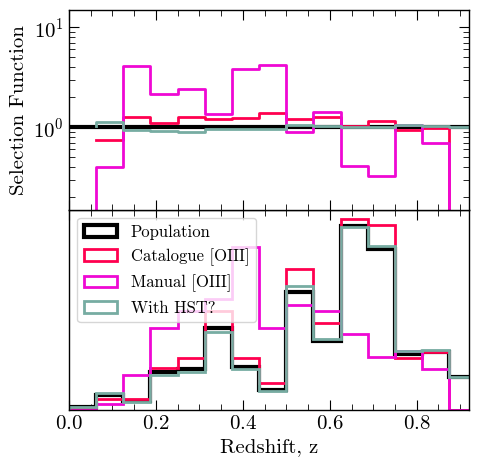

In [10]:
fig, ax = pf.create_plot(size=(4,2))

ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_ylabel('Selection Function')
ax.set_xlabel('Redshift, z')

ax.set_xlim(0,0.92)
ax2.set_ylim(0.15,15)
# ax2.set_ylim(0.15,5)
ax.set_yticks([])

binning = np.linspace(0,1,17)

ax.hist(maintab['Z'], bins=binning, density=True, histtype='step', lw=3, label='Population', edgecolor='k')
globhist, _ = np.histogram(maintab['Z'], bins=binning, density=True)

data = [(maintab[maintab['DETECTED?_OIII']==1])['Z'],tab['z'],ftab['Z']]
labz = ['Catalogue [OIII]',r'Manual [OIII]','With HST?']
colorz = ['#ff004f',"#EF08D4",'#77aca2']

for i,d in enumerate(data):
    ax.hist(d, bins=binning, density=True, histtype='step', label = labz[i], edgecolor=colorz[i], lw=2 )

    hist, bedge = np.histogram(d, bins=binning, density=True)

    ax2.step(bedge[1:], hist/globhist, color=colorz[i], linewidth=2, label = labz[i])
    # pf.smooth_step(ax2,bedge[1:],hist/globhist, color=colorz[i], linewidth=2, label = labz[i])

ax2.plot([-1,100],[1,1], color='black', lw=3, zorder=-1, label='Population')
ax2.set_yscale('log')
ax.legend(fontsize=12)

pf.fix_plot([ax,ax2])
plt.tight_layout()
plt.savefig('figs/selfz.png', dpi=600,bbox_inches='tight')

In [11]:
ax2.get_ylim()

(np.float64(0.15), np.float64(15.0))

In [12]:
def estimate_continuum(line_wavelength, phot_fluxes, phot_wavelengths):
    valid_points = sorted([
        (w, f) for w, f in zip(phot_wavelengths, phot_fluxes)
        if w is not None and f is not None and np.isfinite(f) and f > 0
    ])

    if len(valid_points) < 2:
        return np.nan

    sorted_wavs, sorted_fluxes = zip(*valid_points)
    sorted_wavs = np.array(sorted_wavs)
    sorted_fluxes = np.array(sorted_fluxes)

    if line_wavelength < sorted_wavs[0] or line_wavelength > sorted_wavs[-1]:
        return np.nan

    idx = np.searchsorted(sorted_wavs, line_wavelength)

    if idx == 0 or idx == len(sorted_wavs):
        return np.nan
    if sorted_wavs[idx] == line_wavelength:
        return sorted_fluxes[idx]
    
    wav1, flux1 = sorted_wavs[idx - 1], sorted_fluxes[idx - 1]
    wav2, flux2 = sorted_wavs[idx], sorted_fluxes[idx]

    log_wav1, log_flux1 = np.log(wav1), np.log(flux1)
    log_wav2, log_flux2 = np.log(wav2), np.log(flux2)
    log_line_wav = np.log(line_wavelength)

    m = (log_flux2 - log_flux1) / (log_wav2 - log_wav1)
    log_line_flux = log_flux1 + m * (log_line_wav - log_wav1)

    return np.exp(log_line_flux)

def calculate_continuum_for_table(table, line_wavelength_col, flux_cols, flux_wavelengths):
    continuum_values = []
    for row in table:
        line_wav = row[line_wavelength_col]
        phot_fluxes = [row[col] for col in flux_cols]
        
        if not np.isfinite(line_wav):
            continuum_values.append(np.nan)
            continue

        continuum = estimate_continuum(line_wav, phot_fluxes, flux_wavelengths)
        continuum_values.append(continuum)
        
    return continuum_values

C_ANGSTROM_PER_S = 2.99792458e18

def jansky_to_cgs(jansky, wavelength_angstroms):
    flux_cgs_hz = jansky * 1e-23
    flux_cgs_angstrom = flux_cgs_hz * (C_ANGSTROM_PER_S / (wavelength_angstroms**2))

    return flux_cgs_angstrom

In [13]:
for line in ['oiii5007','oiii4959','hbeta']:
    cont = np.array(calculate_continuum_for_table(final_table, 'WF'+line+'_centroid',['F606W','F814W','F125W','F140W','F160W'],[5921,8057,12471,13924,15396]))*0.3631*1e-6
    cont_corr = jansky_to_cgs(cont, final_table['WF'+line+'_centroid'])*1e21
    final_table['WF'+line+'_ew'] = final_table['WF'+line+'_flux']/cont_corr

In [14]:
cont_corr

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [15]:
final_table

UNIQUE_ID,FIELD_NAME,RA,DEC,Z,Z_ERR,LEAD_LINE,SN,QUALITY,CONFIDENCE,OTHER_LINES,GUO_ID,GUO_SEP,SKELTON_ID,SKELTON_SEP,STELLAR_MASS,DETECTED?_OIII,WFoiii5007_flux,WFoiii5007_flux_err,WFoiii5007_centroid,WFoiii4959_flux,WFoiii4959_flux_err,WFoiii4959_centroid,WFoii_flux,WFoii_flux_err,WFoii_centroid,WFhalpha_flux,WFhalpha_flux_err,WFhalpha_centroid,WFhbeta_flux,WFhbeta_flux_err,WFhbeta_centroid,DETECTED?_Hb,RAJ2000,DEJ2000,F606W,e_F606W,F814W,e_F814W,F125W,e_F125W,F140W,e_F140W,F160W,e_F160W,WFoiii5007_ew,WFoiii4959_ew,WFhbeta_ew
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,,,
int64,str16,float64,float64,float64,float64,str5,float64,str1,int16,str60,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64
117019062,candels-cdfs-17,53.161029297195135,-27.845648854888942,4.793310165405273,0.00023999999393709004,Lya,10.52396752732081,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145034089,candels-cdfs-45,53.04941724959954,-27.792198819978907,4.1996169090271,0.001421791035681963,Lya,5.116736888885498,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145039097,candels-cdfs-45,53.054002647564594,-27.787527318729325,4.439391136169434,0.0016438179882243276,Lya,5.855274200439453,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145044103,candels-cdfs-45,53.065669197780146,-27.79666829596328,4.814822196960449,0.0012466150801628828,Lya,5.613737106323242,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145045104,candels-cdfs-45,53.04976102084865,-27.793577412836758,4.9472455978393555,0.0005344867240637541,Lya,5.00687837600708,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122007063,candels-cdfs-22,53.13911296624889,-27.83634142031768,3.1427299976348877,0.0008500000112690032,Lya,7.440158426679493,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122005056,candels-cdfs-22,53.13780810151262,-27.83360371579142,3.0648000240325928,0.00039000000106170774,Lya,6.531986707112724,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122004055,candels-cdfs-22,53.12691331467025,-27.839296486180462,3.065150022506714,0.0002699999895412475,Lya,8.714166836436174,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_69890/2595802935.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


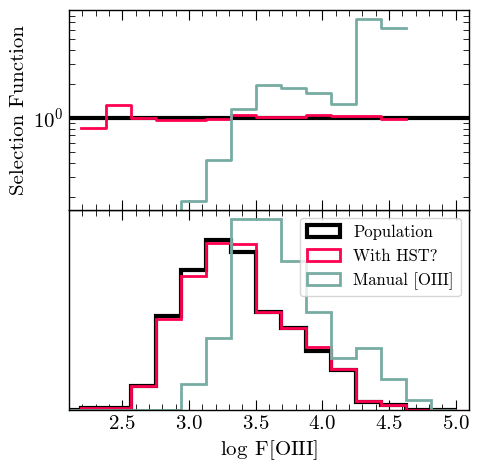

In [16]:
fig, ax = pf.create_plot(size=(4,2))
ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_ylabel('Selection Function')
ax.set_xlabel(r'$\log\;$F[OIII]')
ax.set_yticks([])
ax.set_xlim(2.1,5.1)

binning = np.linspace(2,5,17)

ax.hist(np.log10(final_table['WFoiii5007_flux']), bins=binning, density=True, histtype='step', lw=3, label='Population', edgecolor='k')
globhist, _ = np.histogram(np.log10(final_table['WFoiii5007_flux']), bins=binning, density=True)

data = [(final_table[mask])['WFoiii5007_flux'], tab['oiii5007_flux']]
labz = ['With HST?',r'Manual [OIII]']
colorz = ['#ff004f','#77aca2']


for i,d in enumerate(data):
    d = np.log10(d)
    ax.hist(d, bins=binning, density=True, histtype='step', label = labz[i], edgecolor=colorz[i], lw=2 )
    hist, bedge = np.histogram(d, bins=binning, density=True)
    ax2.step(bedge[1:], hist/globhist, color=colorz[i], linewidth=2, label = labz[i])
    # pf.smooth_step(ax2,bedge[1:],hist/globhist, color=colorz[i], linewidth=2, label = labz[i])

ax2.plot([-1,100],[1,1], color='black', lw=3, zorder=-1, label='Population')
ax2.set_yscale('log')
ax.legend(fontsize=12)

pf.fix_plot([ax,ax2])
plt.tight_layout()
plt.savefig('figs/selflux.png', dpi=600,bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_69890/1397679267.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


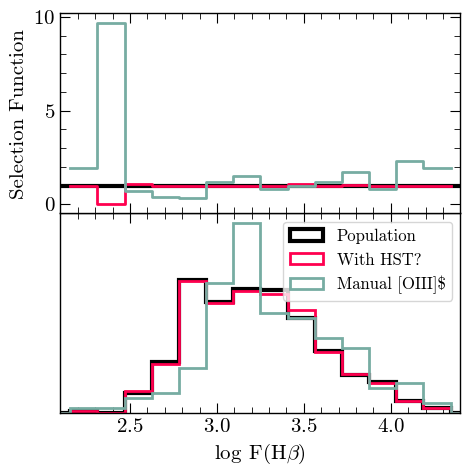

In [17]:
fig, ax = pf.create_plot(size=(4,2))
ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_ylabel('Selection Function')
ax.set_xlabel(r'$\log\;$F(H$\beta$)')
ax.set_yticks([])
ax.set_xlim(2.1,4.4)

binning = np.linspace(2,4.5,17)

ax.hist(np.log10(final_table['WFhbeta_flux']), bins=binning, density=True, histtype='step', lw=3, label='Population', edgecolor='k')
globhist, _ = np.histogram(np.log10(final_table['WFhbeta_flux']), bins=binning, density=True)

data = [(final_table[mask])['WFhbeta_flux'], tab['hbeta_flux']]
labz = ['With HST?',r'Manual [OIII]$']
colorz = ['#ff004f','#77aca2']


for i,d in enumerate(data):
    d = np.log10(d)
    ax.hist(d, bins=binning, density=True, histtype='step', label = labz[i], edgecolor=colorz[i], lw=2 )
    hist, bedge = np.histogram(d, bins=binning, density=True)
    ax2.step(bedge[1:], hist/globhist, color=colorz[i], linewidth=2, label = labz[i])
    # pf.smooth_step(ax2,bedge[1:],hist/globhist, color=colorz[i], linewidth=2, label = labz[i])

ax2.plot([-1,100],[1,1], color='black', lw=3, zorder=-1, label='Population')
# ax2.set_yscale('log')
ax.legend(fontsize=12)

pf.fix_plot([ax,ax2])
plt.tight_layout()
plt.savefig('figs/hbeta.png', dpi=600,bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_69890/2123157464.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


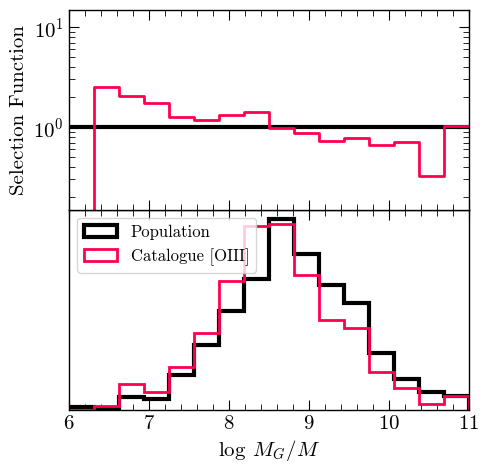

In [18]:
fig, ax = pf.create_plot(size=(4,2))

ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_ylabel('Selection Function')
ax.set_xlabel(r'$\log\;M_{G}/M$')

ax.set_xlim(6,11)
ax2.set_ylim(0.15,15)
# ax2.set_ylim(0.15,5)
ax.set_yticks([])

binning = np.linspace(6,11,17)

ax.hist(maintab['STELLAR_MASS'], bins=binning, density=True, histtype='step', lw=3, label='Population', edgecolor='k')
globhist, _ = np.histogram(maintab['STELLAR_MASS'], bins=binning, density=True)

data = [(maintab[(maintab['DETECTED?_OIII']==1)&(maintab['Z']<1)])['STELLAR_MASS']]
labz = ['Catalogue [OIII]']
colorz = ['#ff004f']

for i,d in enumerate(data):
    ax.hist(d, bins=binning, density=True, histtype='step', label = labz[i], edgecolor=colorz[i], lw=2 )

    hist, bedge = np.histogram(d, bins=binning, density=True)

    ax2.step(bedge[1:], hist/globhist, color=colorz[i], linewidth=2, label = labz[i])
    # pf.smooth_step(ax2,bedge[1:],hist/globhist, color=colorz[i], linewidth=2, label = labz[i])

ax2.plot([-1,100],[1,1], color='black', lw=3, zorder=-1, label='Population')
ax2.set_yscale('log')
ax.legend(fontsize=12)

pf.fix_plot([ax,ax2])
plt.tight_layout()
plt.savefig('figs/selfmg.png', dpi=600,bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_69890/2159155359.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


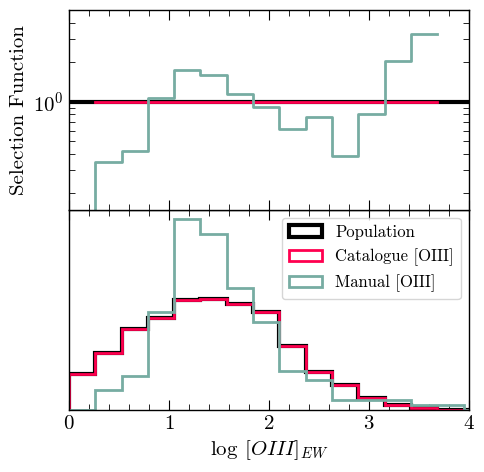

In [19]:
fig, ax = pf.create_plot(size=(4,2))

ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_ylabel('Selection Function')
ax.set_xlabel(r'$\log\;[OIII]_{EW}$')

ax.set_xlim(0,4)
ax2.set_ylim(0.15,5)
# ax2.set_ylim(0.15,5)
ax.set_yticks([])

binning = np.linspace(0,5,20)

ax.hist(np.log10(final_table['WFoiii5007_ew']), bins=binning, density=True, histtype='step', lw=3, label='Population', edgecolor='k')
globhist, _ = np.histogram(np.log10(final_table['WFoiii5007_ew']), bins=binning, density=True)

data = [np.log10((final_table[(final_table['DETECTED?_OIII']==1)&(final_table['Z']<1)])['WFoiii5007_ew']), np.log10(tab['oiii5007_ew'])]
labz = ['Catalogue [OIII]',r'Manual [OIII]']
colorz = ['#ff004f','#77aca2']

for i,d in enumerate(data):
    ax.hist(d, bins=binning, density=True, histtype='step', label = labz[i], edgecolor=colorz[i], lw=2 )

    hist, bedge = np.histogram(d, bins=binning, density=True)

    ax2.step(bedge[1:], hist/globhist, color=colorz[i], linewidth=2, label = labz[i])
    # pf.smooth_step(ax2,bedge[1:],hist/globhist, color=colorz[i], linewidth=2, label = labz[i])

ax2.plot([-1,100],[1,1], color='black', lw=3, zorder=-1, label='Population')
ax2.set_yscale('log')
ax.legend(fontsize=12)

pf.fix_plot([ax,ax2])

plt.tight_layout()
plt.savefig('figs/selfew.png', dpi=600,bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_69890/163860790.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


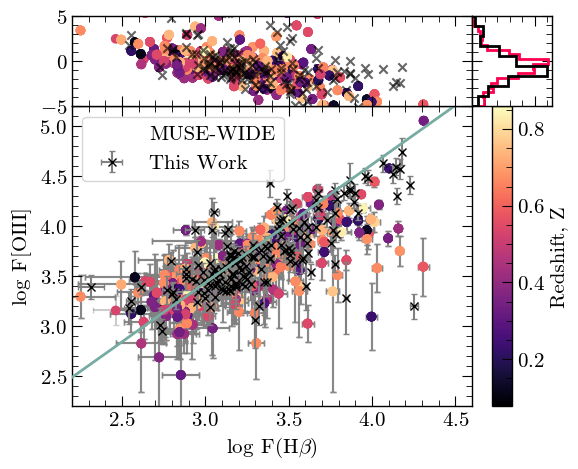

In [20]:

def linear(x, *A):
    return x*A[0]+A[1]
dmask = final_table['Z']<1
fig,ax = pf.create_plot()
colorax = fig.add_axes((1.05,0,0.05,1))

ax2 = fig.add_axes((0,1,1,0.3), sharex=ax)
ax3 = fig.add_axes((1,1,0.2,0.3), sharey=ax2)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)

ax.set_xlabel(r'$\log\;$F(H$\beta$)')
ax.set_ylabel(r'$\log\;$F[OIII]')
ax.set_xlim(2.2,4.6)
ax.set_ylim(2.2,5.2)

ax3.set_ylim(-5,5)

yvals = np.log10(final_table['WFoiii5007_flux'][dmask])
yerr = yvals*(final_table['WFoiii5007_flux_err'][dmask]/final_table['WFoiii5007_flux'][dmask])/3
xvals = np.log10(final_table['WFhbeta_flux'][dmask])
xerr = xvals*(final_table['WFhbeta_flux_err'][dmask]/final_table['WFhbeta_flux'][dmask])/10
rmask = np.isfinite(xvals)&np.isfinite(yvals)&np.isfinite(yerr)&(xvals<4.5)&(xvals>2.4)
null = [0,0]
popt, pcov = curve_fit(linear, xvals[rmask],yvals[rmask],p0=null, absolute_sigma=True, sigma=yerr[rmask])
grid = np.linspace(1,10,100)

ax.plot(grid, linear(grid, *popt), lw=2, color='#77aca2', zorder=10)

sc = ax.scatter(xvals,yvals, c=final_table[dmask]['Z'],cmap='magma', label='MUSE-WIDE')

resd = (yvals-linear(xvals,*popt))/yerr
ax2.scatter(xvals,resd, c=final_table[dmask]['Z'],cmap='magma')
ax3.hist(resd, orientation='horizontal', density=True, bins=np.linspace(-5,5,20), histtype='step', color='#ff004f', lw=2)

ax.errorbar(xvals,yvals, xerr=xerr, yerr=yerr, fmt='none', capsize=2, ecolor='gray', alpha=0.4, zorder=-10)

yvals2 = np.log10(tab['oiii5007_flux'])
yerr2 = yvals2*(tab['oiii5007_flux_err']/tab['oiii5007_flux'])
xvals2 = np.log10(tab['hbeta_flux'])
xerr2 = xvals2*(tab['hbeta_flux_err']/tab['hbeta_flux'])/10

sc2 = ax.errorbar(xvals2,yvals2, fmt='x', color='k', yerr=np.abs(yerr2), xerr=np.abs(xerr2),capsize=2, ecolor='gray',label='This Work')
resd2 = (yvals2-linear(xvals2,*popt))/yerr2
ax2.scatter(xvals2,resd2,color='k', marker='x', alpha=0.6)
ax3.hist(resd2, orientation='horizontal', density=True, bins=np.linspace(-5,5,10), histtype='step', color='k', lw=2)

ax.legend()


plt.colorbar(sc, label='Redshift, Z', cax=colorax)
pf.fix_plot([ax,ax2,ax3,colorax])

plt.tight_layout()
plt.savefig('figs/zdist1.png', dpi=600,bbox_inches='tight')

In [21]:
linear(grid, *popt)

array([ 1.07286988,  1.18034009,  1.28781029,  1.3952805 ,  1.5027507 ,
        1.61022091,  1.71769111,  1.82516131,  1.93263152,  2.04010172,
        2.14757193,  2.25504213,  2.36251234,  2.46998254,  2.57745275,
        2.68492295,  2.79239315,  2.89986336,  3.00733356,  3.11480377,
        3.22227397,  3.32974418,  3.43721438,  3.54468459,  3.65215479,
        3.75962499,  3.8670952 ,  3.9745654 ,  4.08203561,  4.18950581,
        4.29697602,  4.40444622,  4.51191643,  4.61938663,  4.72685683,
        4.83432704,  4.94179724,  5.04926745,  5.15673765,  5.26420786,
        5.37167806,  5.47914827,  5.58661847,  5.69408867,  5.80155888,
        5.90902908,  6.01649929,  6.12396949,  6.2314397 ,  6.3389099 ,
        6.44638011,  6.55385031,  6.66132051,  6.76879072,  6.87626092,
        6.98373113,  7.09120133,  7.19867154,  7.30614174,  7.41361195,
        7.52108215,  7.62855235,  7.73602256,  7.84349276,  7.95096297,
        8.05843317,  8.16590338,  8.27337358,  8.38084379,  8.48

In [22]:
def crossmatch_vizier(galaxy_table):
    vizier_catalog = "J/A+A/590/A31"
    v = Vizier(
        columns=['ID', 'RAJ2000', 'DEJ2000', 
                'F606W', 'e_F606W', # V-band
                'F814W', 'e_F814W', # I-band
                'F125W', 'e_F125W', # J-band
                'F140W', 'e_F140W', # H-band (intermediate)
                'F160W', 'e_F160W'  # H-band
                ],
        row_limit=-1 # Get all matching rows
    )
    coords = SkyCoord(ra=galaxy_table['ra'], dec=galaxy_table['dec'], unit=(u.deg, u.deg))
    result = v.query_region(coords, radius=100 * u.arcsec, catalog=vizier_catalog)
    if result:
        return result[0]
    else:
        return Table()


In [23]:
res = crossmatch_vizier(tab)
res

<Table length=0>
<No columns>

In [24]:
tab

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d07m28pt35s-28d53m18pt439s,28.124541666666662,-28.888455277777776,0.3685089804926993,26.18756698942221,1,0,0,nan,nan,8.141642654203588,0.004260300187639276,11.062827619803281,2.277642553607944,717.2840511320709,242.072037707888,0.4127,macs0152m28,4124.469894464831,87.899338157534,35.219154485348156,2.0501406651496796,5006.835951321285,2.000851928624639,47.66104780419961,1185.2825861364677,136.72975380269563,5.898970866095592,1.8880619600846873,4958.900222500991,1.6770166740703585,39.12405443693391,1761.464896696335,1068.6135356727189,29.998235596428906,91.72048342399984,3725.300846892047,5.449503026807009,184.65485291083476,2884.5577145722427,1618.3931634975047,49.243829643832576,138.90878074330303,3728.766711514383,5.449503026807009,184.516

In [25]:
final_table

UNIQUE_ID,FIELD_NAME,RA,DEC,Z,Z_ERR,LEAD_LINE,SN,QUALITY,CONFIDENCE,OTHER_LINES,GUO_ID,GUO_SEP,SKELTON_ID,SKELTON_SEP,STELLAR_MASS,DETECTED?_OIII,WFoiii5007_flux,WFoiii5007_flux_err,WFoiii5007_centroid,WFoiii4959_flux,WFoiii4959_flux_err,WFoiii4959_centroid,WFoii_flux,WFoii_flux_err,WFoii_centroid,WFhalpha_flux,WFhalpha_flux_err,WFhalpha_centroid,WFhbeta_flux,WFhbeta_flux_err,WFhbeta_centroid,DETECTED?_Hb,RAJ2000,DEJ2000,F606W,e_F606W,F814W,e_F814W,F125W,e_F125W,F140W,e_F140W,F160W,e_F160W,WFoiii5007_ew,WFoiii4959_ew,WFhbeta_ew
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,0.3631 uJy,,,
int64,str16,float64,float64,float64,float64,str5,float64,str1,int16,str60,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64
117019062,candels-cdfs-17,53.161029297195135,-27.845648854888942,4.793310165405273,0.00023999999393709004,Lya,10.52396752732081,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145034089,candels-cdfs-45,53.04941724959954,-27.792198819978907,4.1996169090271,0.001421791035681963,Lya,5.116736888885498,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145039097,candels-cdfs-45,53.054002647564594,-27.787527318729325,4.439391136169434,0.0016438179882243276,Lya,5.855274200439453,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145044103,candels-cdfs-45,53.065669197780146,-27.79666829596328,4.814822196960449,0.0012466150801628828,Lya,5.613737106323242,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
145045104,candels-cdfs-45,53.04976102084865,-27.793577412836758,4.9472455978393555,0.0005344867240637541,Lya,5.00687837600708,c,1,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122007063,candels-cdfs-22,53.13911296624889,-27.83634142031768,3.1427299976348877,0.0008500000112690032,Lya,7.440158426679493,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122005056,candels-cdfs-22,53.13780810151262,-27.83360371579142,3.0648000240325928,0.00039000000106170774,Lya,6.531986707112724,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan
122004055,candels-cdfs-22,53.12691331467025,-27.839296486180462,3.065150022506714,0.0002699999895412475,Lya,8.714166836436174,c,2,none,0,nan,0,nan,0.0,0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0,--,--,--,--,--,--,--,--,--,--,--,--,nan,nan,nan


True

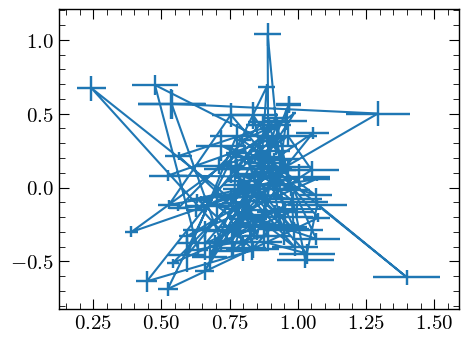

In [ ]:
fig, ax = pf.create_plot()

R23 = (final_table['WFoiii5007_flux']+final_table['WFoiii4959_flux']+final_table['WFoii_flux'])/final_table['WFhbeta_flux']
R23_Ne = np.sqrt(final_table['WFoiii5007_flux_err']**2+
                final_table['WFoiii4959_flux_err']**2+
                final_table['WFoii_flux_err']**2)
R23_e = R23*np.sqrt((R23_Ne/(R23*final_table['WFhbeta_flux']))**2+
                    (final_table['WFhbeta_flux_err']/final_table['WFhbeta_flux'])**2)
log_R23_e = 0.434*R23_e/R23

O32 = (final_table['WFoiii5007_flux']+final_table['WFoiii4959_flux'])/(final_table['WFoii_flux'])
O32_Ne = np.sqrt(final_table['WFoiii5007_flux_err']**2+
                final_table['WFoiii4959_flux_err']**2)
O32_e = O32*np.sqrt((O32_Ne/(O32*final_table['WFoii_flux']))**2+
                    (final_table['WFoii_flux_err']/final_table['WFoii_flux'])**2)
logO32_e = 0.434*O32_e/O32
mask = ((O32_e/O32)<.3)&((R23_e/R23)<.3)

ax.errorbar(np.log10(R23)[mask],np.log10(O32)[mask], xerr = log_R23_e[mask], yerr=logO32_e[mask])

poptable = Table([np.log10(R23),log_R23_e,np.log10(O32),logO32_e,
                  final_table['WFoiii5007_ew'],final_table['WFhbeta_ew'],final_table['Z']],
                  names=['log10R23','log10R23_e','log10O32','log10O32_e','oiiiEW','hbetaEW','z'])
poptable.write('poptable.csv', overwrite=True)

pf.fix_plot([ax])


In [42]:
np.nanmax(O32_e/O32)

np.float64(0.7112734197985136)